In [1]:
pip install rdkit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install dgllife

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Loading file to Pandas DF + Add SMILES for primary and secondary ligand + solvent one hot encoder + Molecules structures

In [3]:
from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import pandas as pd
import numpy as np
import seaborn as sn
#---------------------- RDKit packages
from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
#------------------- progress bar
from tqdm import tqdm
#------------------- hide warning
import warnings
from urllib.request import urlopen
from urllib.parse import quote
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import Image, display
from IPython.display import display, HTML
import base64
from PIL import Image as PILImage
from io import BytesIO
from sklearn.preprocessing import OneHotEncoder
warnings.filterwarnings('ignore')


dataset=pd.read_excel("../../data/SF_DATA_EMISSION_PEAK.xlsx", sheet_name='EQE_CLEANED')
#dataset=dataset_full.iloc[:5]

master_smiles_map = {
    'ethanamine': 'CCN',
    'propan-1-amine': 'CCCN',
    'propan-2-amine': 'CC(N)C',
    'butan-1-amine': 'CCCCN',
    'pentan-1-amine': 'CCCCCN',
    'propane-1,3-diamine': 'NCCCN',
    'pentane-1,5-diamine': 'NCCCCCN',
    'N-(2-bromoethyl)propane-1,3-diamine': 'BrCCNCCCN',
    '2-phenylethan-1-amine': 'NCCc1ccccc1',
    '1-phenylethan-1-amine': 'CC(N)c1ccccc1',
    '3,3-diphenylpropan-1-amine': 'NCCC(c1ccccc1)c2ccccc2',
    '4-phenylbutan-1-amine': 'NCCCCc1ccccc1',
    '4-phenylbutan-2-amine': 'CC(N)CCc1ccccc1',
    'benzene-1,4-dimethanamine': 'NCc1ccc(CN)cc1',
    "[1,1':3',1'':3'',1'''-quaterphenyl]-4-ylmethanamine": 
        'NCc1ccc(cc1)-c2cccc(c2)-c3cccc(c3)-c4ccccc4',
    '1-(naphthalen-1-yl)ethan-1-amine': 'CC(N)c1cccc2ccccc12',
    'naphthalen-1-ylmethanamine': 'NCc1cccc2ccccc12',
    '2-(2-fluorophenyl)ethan-1-amine': 'NCCc1c(F)cccc1',
    '2-(3-fluorophenyl)ethan-1-amine': 'NCCc1cc(F)ccc1',
    '2-(4-fluorophenyl)ethan-1-amine': 'NCCc1ccc(F)cc1',
    '2-(2-methoxyphenyl)ethan-1-amine': 'NCCc1c(OC)cccc1',
    '2-(3-methoxyphenyl)ethan-1-amine': 'COc1cc(CCN)ccc1',
    '2-(4-methoxyphenyl)ethan-1-amine': 'COc1ccc(CCN)cc1',
    '2-phenoxyethan-1-amine': 'NCCOc1ccccc1',
    '2-(thiophen-2-yl)ethan-1-amine': 'NCCc1cccs1',
    "2-[5-(2,2'-dimethyl-[1,1'-biphenyl]-4-yl)thiophen-2-yl]ethan-1-amine":
        'Cc1ccccc1-c2c(C)cc(cc2)-c3ccc(CCN)s3',
    "2-[5-(3',5'-dimethyl-[1,1'-biphenyl]-4-yl)thiophen-2-yl]ethan-1-amine":
        'Cc1cc(C)cc(c1)-c2ccc(cc2)-c3ccc(CCN)s3',
    '2-[2-(2-aminoethoxy)ethoxy]ethan-1-amine': 'NCCOCCOCCN',
    'adamantan-1-amine': 'NC12CC3CC(C1)CC(C3)C2',
    'ethanimidamide': 'CC(=N)N',
    'guanidine': 'NC(=N)N'
}

#-----------------------
def CIRconvert(ids):
    if pd.isna(ids):
        return None
    try:
        url = 'http://cactus.nci.nih.gov/chemical/structure/' + quote(ids) + '/smiles'
        ans = urlopen(url).read().decode('utf8')
        return ans
    except:
        if ids in master_smiles_map:
            return master_smiles_map[ids]
        return 'Could not find SMILES'
        
dataset["PRIMARY_ORGANIC_SPACER_SMILES"]=dataset["PRIMARY_ORGANIC_SPACER_IUPAC"].apply(CIRconvert)
dataset["SECONDARY_ORGANIC_SPACER_SMILES"]=dataset["SECONDARY_ORGANIC_SPACER_IUPAC"].apply(CIRconvert)

#-------------------------
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
solvent_df = dataset[['SOLVENT']]
encoded_array = encoder.fit_transform(solvent_df)
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['SOLVENT']))
dataset = pd.concat([dataset.drop('SOLVENT', axis=1), encoded_df], axis=1)

#----------------------------
def smile_to_mol(smiles):
    if not smiles:
        return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol
    except:
        return None
    
dataset["PRIMARY_ORGANIC_SPACER_MOL"]=dataset["PRIMARY_ORGANIC_SPACER_SMILES"].apply(smile_to_mol)
dataset["SECONDARY_ORGANIC_SPACER_MOL"]=dataset["SECONDARY_ORGANIC_SPACER_SMILES"].apply(smile_to_mol)

#----------------------------
def render_mol(mol):
    if not mol:
        return None
    img = Draw.MolToImage(mol)
    img_buffer = BytesIO()
    img.save(img_buffer, format="PNG")
    img_str = base64.b64encode(img_buffer.getvalue()).decode("utf-8")
    return f'<img src="data:image/png;base64,{img_str}" width="150">'

dataset["PRIMARY_ORGANIC_SPACER_STRUCT"]=dataset["PRIMARY_ORGANIC_SPACER_MOL"].apply(render_mol)
dataset["SECONDARY_ORGANIC_SPACER_STRUCT"]=dataset["SECONDARY_ORGANIC_SPACER_MOL"].apply(render_mol)

#---------------------------
#display(dataset)
#dataset.drop(columns='Mol', axis=1, inplace=True)
#dataset.drop(columns='Struct', axis=1, inplace=True)

#display(HTML(dataset.to_html(escape=False)))
with open('results_table.html', 'w', encoding='utf-8') as f:
    f.write(dataset.to_html(escape=False))
#-----------------

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
dataset.head()

,REFERENCE_DOI,IS_MIXED_SPACERS_SPACER,PRIMARY_ORGANIC_SPACER_IUPAC,CL_PRIMARY_ORGANIC_HALIDE,BR_PRIMARY_ORGANIC_HALIDE,I_PRIMARY_ORGANIC_HALIDE,PRIMARY_SPACER_FRACTION,SECONDARY_ORGANIC_SPACER_IUPAC,CL_SECONDARY_ORGANIC_HALIDE,BR_SECONDARY_ORGANIC_HALIDE,I_SECONDARY_ORGANIC_HALIDE,SECONDARY_SPACER_FRACTION,SPACER_TO_PB_RATIO,PbCl2,PbBr2,PbI2,CsCl_TO_Pb,CsBr_TO_Pb,CsI_TO_Pb,RbBr_TO_Pb,RbI_TO_Pb,FABr_TO_Pb,FAI_TO_Pb,MABr_TO_Pb,MAI_TO_Pb,EMISSION_PEAK_NM,PHOTON_ENERGY_EV,Additive,Additive ratio,Processing_Temp_C,Annealing_Time_min,HTL,ETL,EQE_percent,PRIMARY_ORGANIC_SPACER_SMILES,SECONDARY_ORGANIC_SPACER_SMILES,SOLVENT_DMF,SOLVENT_DMF:DMSO,SOLVENT_DMSO,SOLVENT_NMP,PRIMARY_ORGANIC_SPACER_MOL,SECONDARY_ORGANIC_SPACER_MOL,PRIMARY_ORGANIC_SPACER_STRUCT,SECONDARY_ORGANIC_SPACER_STRUCT
0,10.1002/aelm.202201199,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.67,0.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.66,0.0,0.0,0.0,530,2.34,NaN,0.0,80.0,60.0,PEDOT:PSS/PSS-Na,TPBI/LiF,12.71,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x000001853DE...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None
1,10.1002/aelm.202201199,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.67,0.0,1.0,0.0,0.0,0.0,0.0,0.33,0.0,0.66,0.0,0.0,0.0,530,2.34,NaN,0.0,80.0,60.0,PEDOT:PSS/PSS-Na,TPBI/LiF,18.92,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x000001853DE...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None
2,10.1002/adom.202302664,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.40,0.0,1.0,0.0,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,512,2.42,NaN,0.0,80.0,5.0,PVK,TPBI/LiF,4.26,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x000001853DE...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None
3,10.1002/adom.202302664,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.40,0.0,1.0,0.0,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,512,2.42,TPBi,1.0,80.0,5.0,PVK,TPBI/LiF,5.08,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x000001853DE...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None
4,10.1002/adom.202302664,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.40,0.0,1.0,0.0,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,512,2.42,TPBi,2.0,80.0,5.0,PVK,TPBI/LiF,7.05,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x000001853DE...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None


In [4]:
print(dataset.shape)
dataset.replace("NaN", np.nan, inplace=True)
dataset.replace("N/A", np.nan, inplace=True)

dataset['Additive'] = dataset['Additive'].fillna('None').astype(str)
dataset['HTL'] = dataset['HTL'].fillna('Unknown_HTL').astype(str)
dataset['ETL'] = dataset['ETL'].fillna('Unknown_ETL').astype(str)
dataset['Processing_Temp_C'] = pd.to_numeric(dataset['Processing_Temp_C'])
dataset['Processing_Temp_C'] = dataset['Processing_Temp_C'].fillna(dataset['Processing_Temp_C'].median())

dataset['Annealing_Time_min'] = pd.to_numeric(dataset['Annealing_Time_min'])
dataset['Annealing_Time_min'] = dataset['Annealing_Time_min'].fillna(dataset['Annealing_Time_min'].median())
print(dataset.tail())

(266, 44)
          REFERENCE_DOI  IS_MIXED_SPACERS_SPACER PRIMARY_ORGANIC_SPACER_IUPAC  \
261  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   
262  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   
263  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   
264  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   
265  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   

     CL_PRIMARY_ORGANIC_HALIDE  BR_PRIMARY_ORGANIC_HALIDE  \
261                          0                          1   
262                          0                          1   
263                          0                          1   
264                          0                          1   
265                          0                          1   

     I_PRIMARY_ORGANIC_HALIDE  PRIMARY_SPACER_FRACTION  \
261                         0                      1.0   
262                 

2D Molecular discriptors - All existing features + 200 Molecular discriptors

In [5]:
calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
desc_names = calc.GetDescriptorNames()

def get_2d_descriptors_safe(smiles):
    if pd.isna(smiles) or str(smiles).strip() == "":
        return [None] * len(desc_names)
    
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return [None] * len(desc_names)
        
        # Calculate descriptors (Notice we do NOT AddHs here!)
        return calc.CalcDescriptors(mol)
    except Exception:
        return [None] * len(desc_names)

primary_smiles = dataset['PRIMARY_ORGANIC_SPACER_SMILES'].dropna().unique().tolist()
secondary_smiles = dataset['SECONDARY_ORGANIC_SPACER_SMILES'].dropna().unique().tolist()
unique_smiles = list(set(primary_smiles + secondary_smiles))
print(f"Found {len(unique_smiles)} unique molecules. Calculating {len(desc_names)} descriptors...")


features_dict = {}
for sm in unique_smiles:
    features_dict[sm] = get_2d_descriptors_safe(sm)

df_unique_features = pd.DataFrame.from_dict(features_dict, orient='index', columns=desc_names)
df_primary_features = df_unique_features.add_prefix('Pri_')
df_secondary_features = df_unique_features.add_prefix('Sec_')

dataset = dataset.merge(
    df_primary_features, 
    how='left', 
    left_on='PRIMARY_ORGANIC_SPACER_SMILES', 
    right_index=True
)

dataset = dataset.merge(
    df_secondary_features, 
    how='left', 
    left_on='SECONDARY_ORGANIC_SPACER_SMILES', 
    right_index=True
)

print("\n--- Featurization Complete! ---")

columns_to_omit = ['REFERENCE_DOI', 'PRIMARY_ORGANIC_SPACER_IUPAC', 'SECONDARY_ORGANIC_SPACER_IUPAC', 'PRIMARY_ORGANIC_SPACER_SMILES', 'SECONDARY_ORGANIC_SPACER_SMILES', 'PRIMARY_ORGANIC_SPACER_MOL', 'SECONDARY_ORGANIC_SPACER_MOL', 'PRIMARY_ORGANIC_SPACER_STRUCT', 'SECONDARY_ORGANIC_SPACER_STRUCT']
dataset_final = dataset.drop(columns=columns_to_omit)
#dataset_final = dataset_final.fillna(0)
dataset_final.head()
print(dataset_final.shape)

Found 29 unique molecules. Calculating 217 descriptors...

--- Featurization Complete! ---
(266, 469)


Data split to training and testing - Stratified splitting + Choosing Y

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
sklearn.set_config(enable_metadata_routing=True)

X = dataset_final.drop(columns=['EQE_percent'])
y = dataset_final['EQE_percent']

# ==========================================
# STRICTER STRATIFICATION FOR SMALL DATASETS
# ==========================================

def group_rare_categories(series, min_count=3):
    counts = series.value_counts()
    rare_categories = counts[counts < min_count].index
    return series.replace(rare_categories, 'Other')

# Clean individual categorical columns
htl_clean = group_rare_categories(X['HTL'].astype(str))
etl_clean = group_rare_categories(X['ETL'].astype(str))
additive_clean = group_rare_categories(X['Additive'].astype(str))

# Handle continuous/numeric columns 
mixed_spacer = (X['IS_MIXED_SPACERS_SPACER'] > 0).astype(int).astype(str)
additive_presence = (X['Additive ratio'] > 0).astype(int).astype(str)

# Create the composite profile string
stratify_series = (
    mixed_spacer + "_" + 
    additive_clean + "_" + 
    additive_presence + "_" + 
    htl_clean + "_" + 
    etl_clean
)

# STRICT GLOBAL PRUNING: Any combination appearing less than 5 times is grouped
val_counts = stratify_series.value_counts()
# Changed threshold from 2 to 5 to prevent the test_size > classes error
rare_profiles = val_counts[val_counts < 5].index 
stratify_series = stratify_series.replace(rare_profiles, 'Rare_Combined_Profile')

stratify_col = stratify_series

# Perform the Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=stratify_col
)

print(f"Successfully created {stratify_col.nunique()} distinct stratify profiles.")
print(f"Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")

Successfully created 15 distinct stratify profiles.
Training set: 212 samples | Test set: 54 samples


Feature elimination by 1) Corelation matrices and 2) RFECV  (Recusive Feature Elimination using Cross Validation)

In [7]:
char_columns=['Additive', 'Additive ratio', 'HTL', 'ETL']

X_train_char=X_train[char_columns]
X_train_num=X_train.drop(columns=char_columns)

X_test_char=X_test[char_columns]
X_test_num=X_test.drop(columns=char_columns)

print(X_test_char.head())
print(X_test_num.head())

        Additive  Additive ratio            HTL       ETL
241         None             0.0  NiOx/PTAA/PVK  TPBi/LiF
20   CAL-Arg CDs             1.0      PEDOT:PSS  TPBI/LiF
263         None             0.0  NiOx/PTAA/PVK  TPBi/LiF
21          None             0.0       Poly-TPD  TPBI/LiF
242         None             0.0  NiOx/PTAA/PVK  TPBi/LiF
     IS_MIXED_SPACERS_SPACER  CL_PRIMARY_ORGANIC_HALIDE  \
241                        0                          0   
20                         1                          0   
263                        0                          0   
21                         0                          0   
242                        0                          0   

     BR_PRIMARY_ORGANIC_HALIDE  I_PRIMARY_ORGANIC_HALIDE  \
241                          1                         0   
20                           1                         0   
263                          1                         0   
21                           0                         1 

In [8]:
corr_matrix = X_train_num.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
print(f"Dropping {len(to_drop)} highly correlated redundant features.")

X_train_uncorr = X_train_num.drop(columns=to_drop)
X_test_uncorr = X_test_num.drop(columns=to_drop)

#-----------RFECV---------
weights = compute_sample_weight(
    class_weight='balanced', 
    y=stratify_col.loc[X_train_num.index]
)







# 2. Train the Random Forest Feature Selector WITH the weights
selector_model = RandomForestRegressor(n_estimators=100, random_state=42)
selector_model.fit(X_train_uncorr, y_train, sample_weight=weights) # <-- Pass weights here!


# Select features that have an importance higher than the average
selector = SelectFromModel(selector_model, prefit=True)
selected_feature_indices = selector.get_support(indices=True)

# Get the names of the selected features
best_features = X_train_uncorr.columns[selected_feature_indices]
print(f"Final selected features ({len(best_features)}): \n{best_features.tolist()}")

# STEP 4: Create final datasets with only the best features
X_train_final = X_train_uncorr[best_features]
X_test_final = X_test_uncorr[best_features]

print(f"\nFinal Training Data Shape: {X_train_final.shape}")
print(f"Final Testing Data Shape: {X_test_final.shape}")

Dropping 150 highly correlated redundant features.
Final selected features (19): 
['PRIMARY_SPACER_FRACTION', 'SPACER_TO_PB_RATIO', 'CsBr_TO_Pb', 'CsI_TO_Pb', 'RbBr_TO_Pb', 'FABr_TO_Pb', 'FAI_TO_Pb', 'MABr_TO_Pb', 'EMISSION_PEAK_NM', 'Processing_Temp_C', 'Annealing_Time_min', 'SOLVENT_DMF:DMSO', 'SOLVENT_DMSO', 'Pri_BCUT2D_LOGPLOW', 'Pri_BCUT2D_MRLOW', 'Pri_PEOE_VSA7', 'Pri_EState_VSA5', 'Sec_SMR_VSA5', 'Sec_EState_VSA7']

Final Training Data Shape: (212, 19)
Final Testing Data Shape: (54, 19)


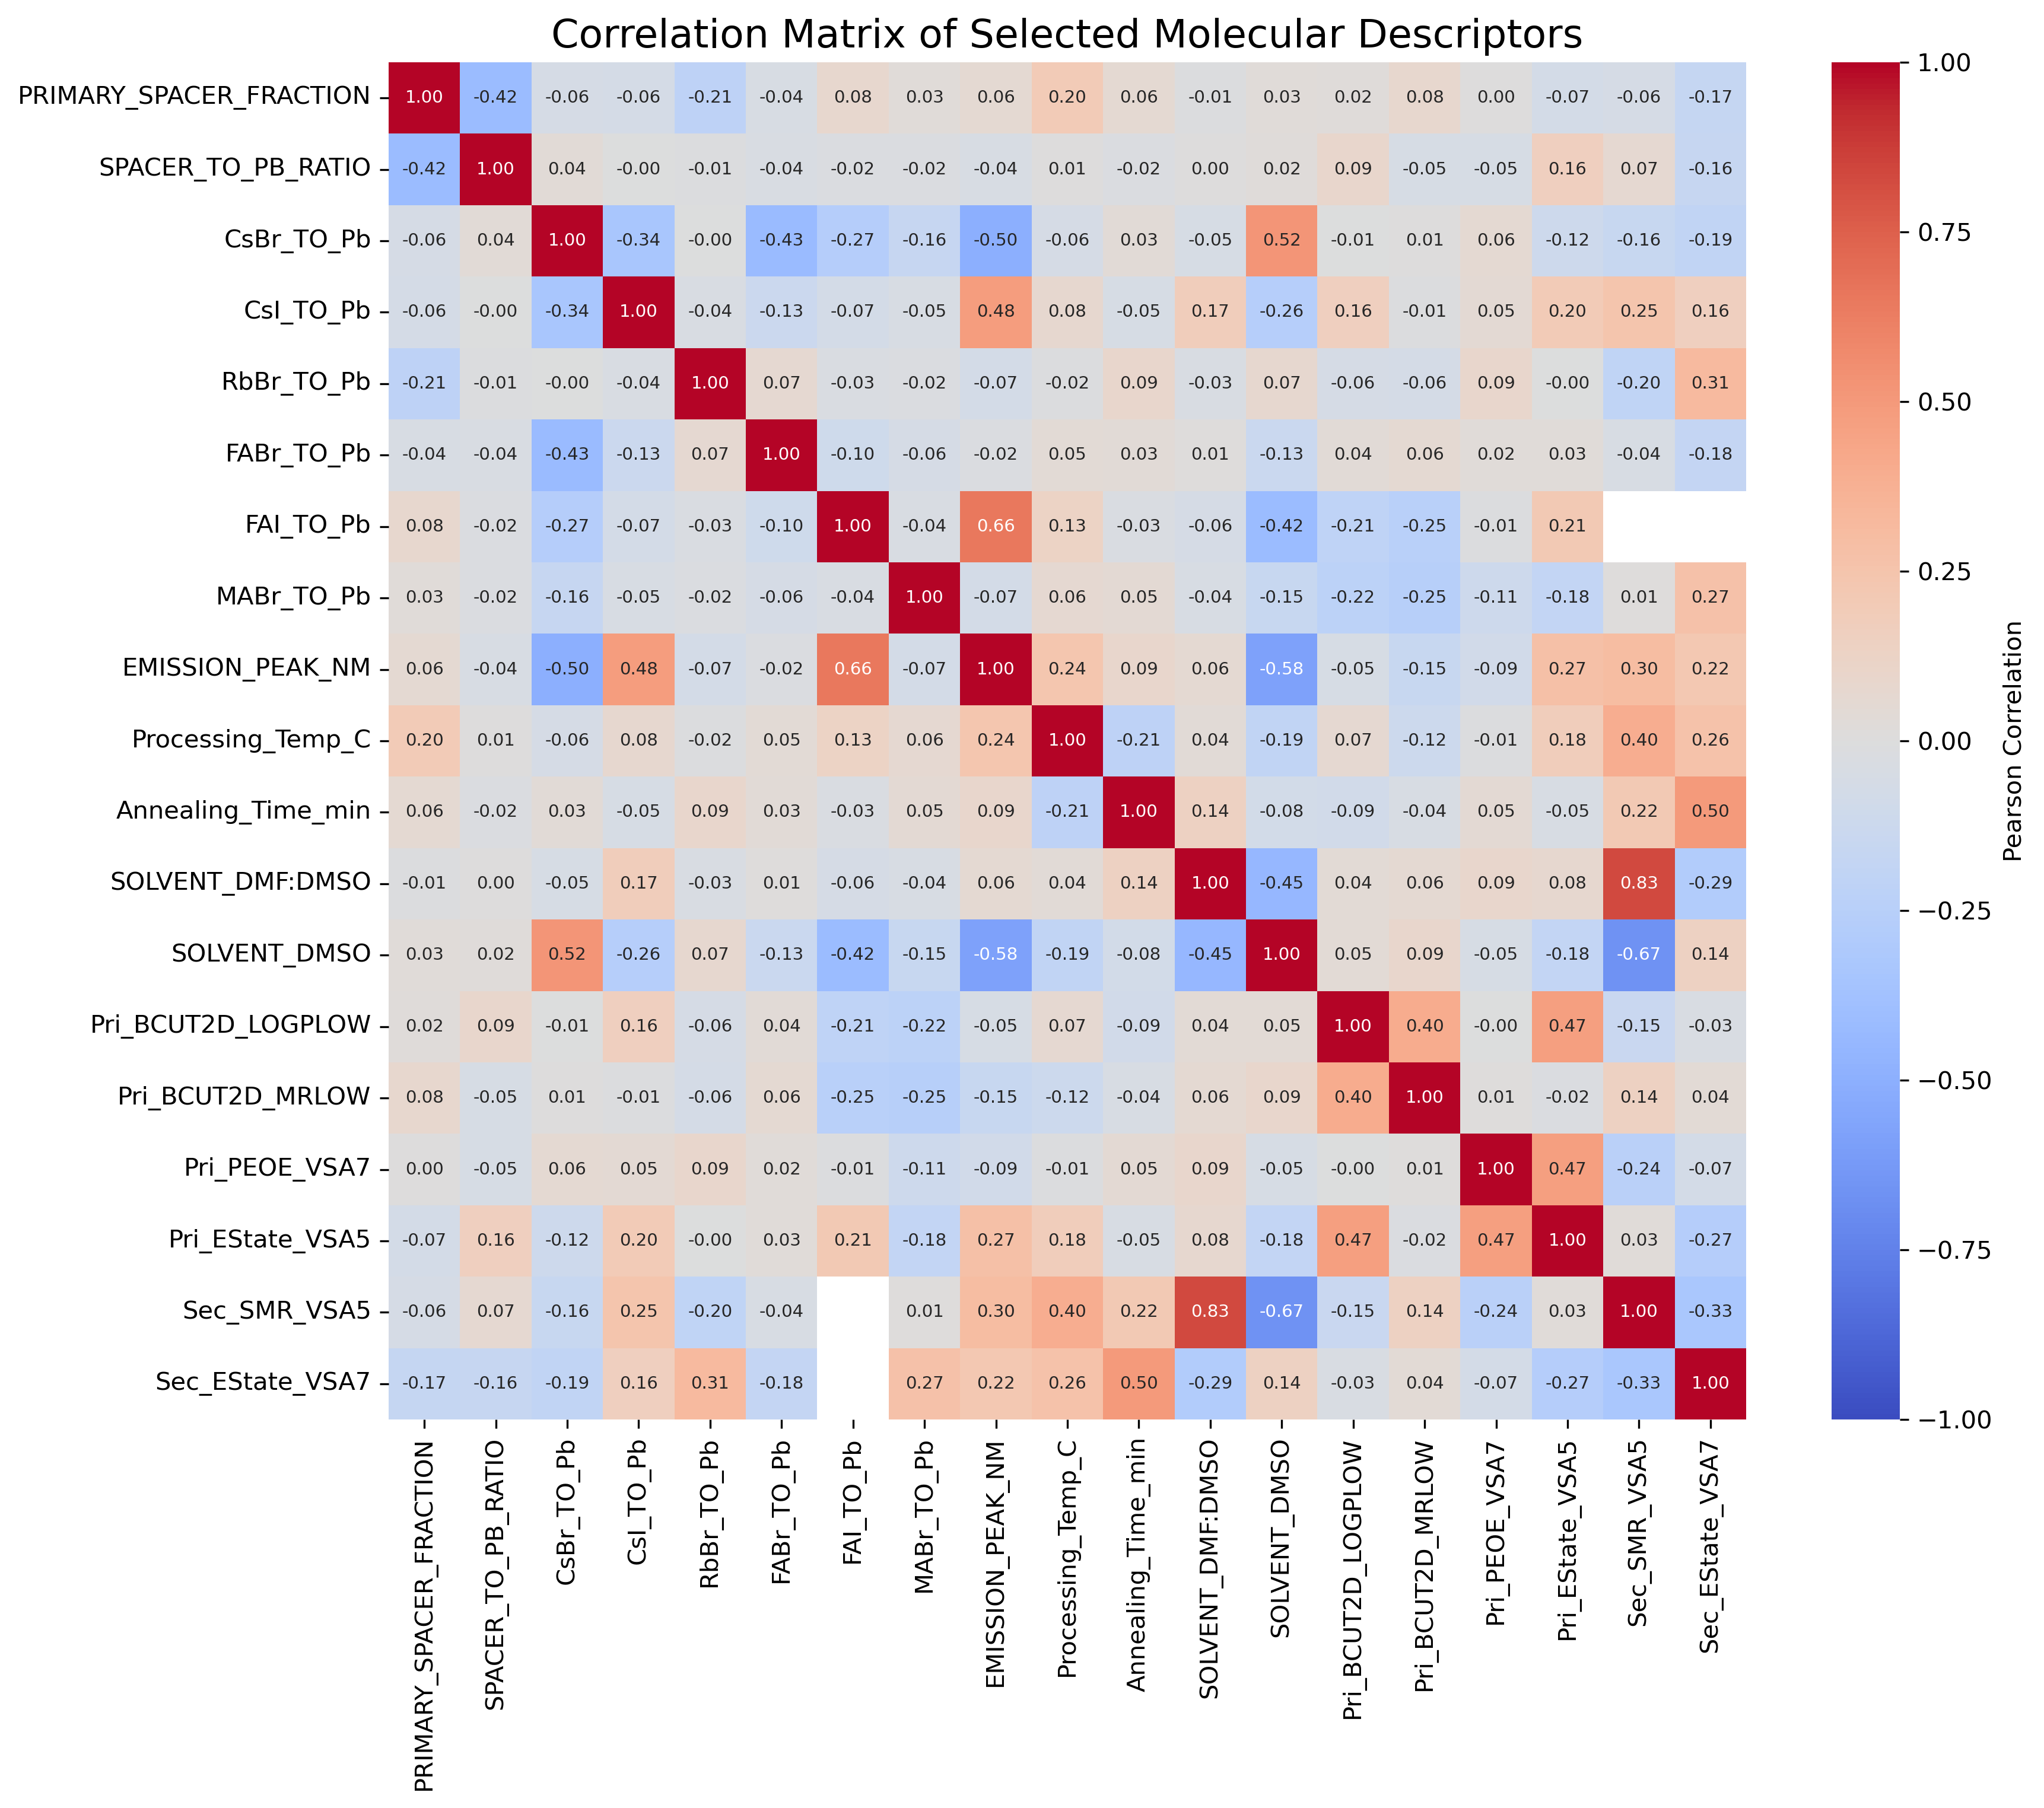

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10), dpi=300) 

# ERROR FIX: Add numeric_only=True to ignore the 'HTL', 'ETL', and 'Additive' strings
final_corr = X_train_final.corr(numeric_only=True)

# heatmap
sns.heatmap(final_corr, 
            annot=True,          
            fmt=".2f",           
            cmap='coolwarm',     
            vmin=-1, vmax=1, 
            square=True, 
            annot_kws={"size": 7}, # Shrunk the numbers so they don't overlap
            cbar_kws={'label': 'Pearson Correlation'})

plt.title("Correlation Matrix of Selected Molecular Descriptors", fontsize=16)

# Ensure labels fit nicely
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

# Saved with 'EQE' in the name since we are forecasting EQE now
plt.savefig("Figure_2_Correlation_Heatmap_Clean_EQE.png") 
plt.show()

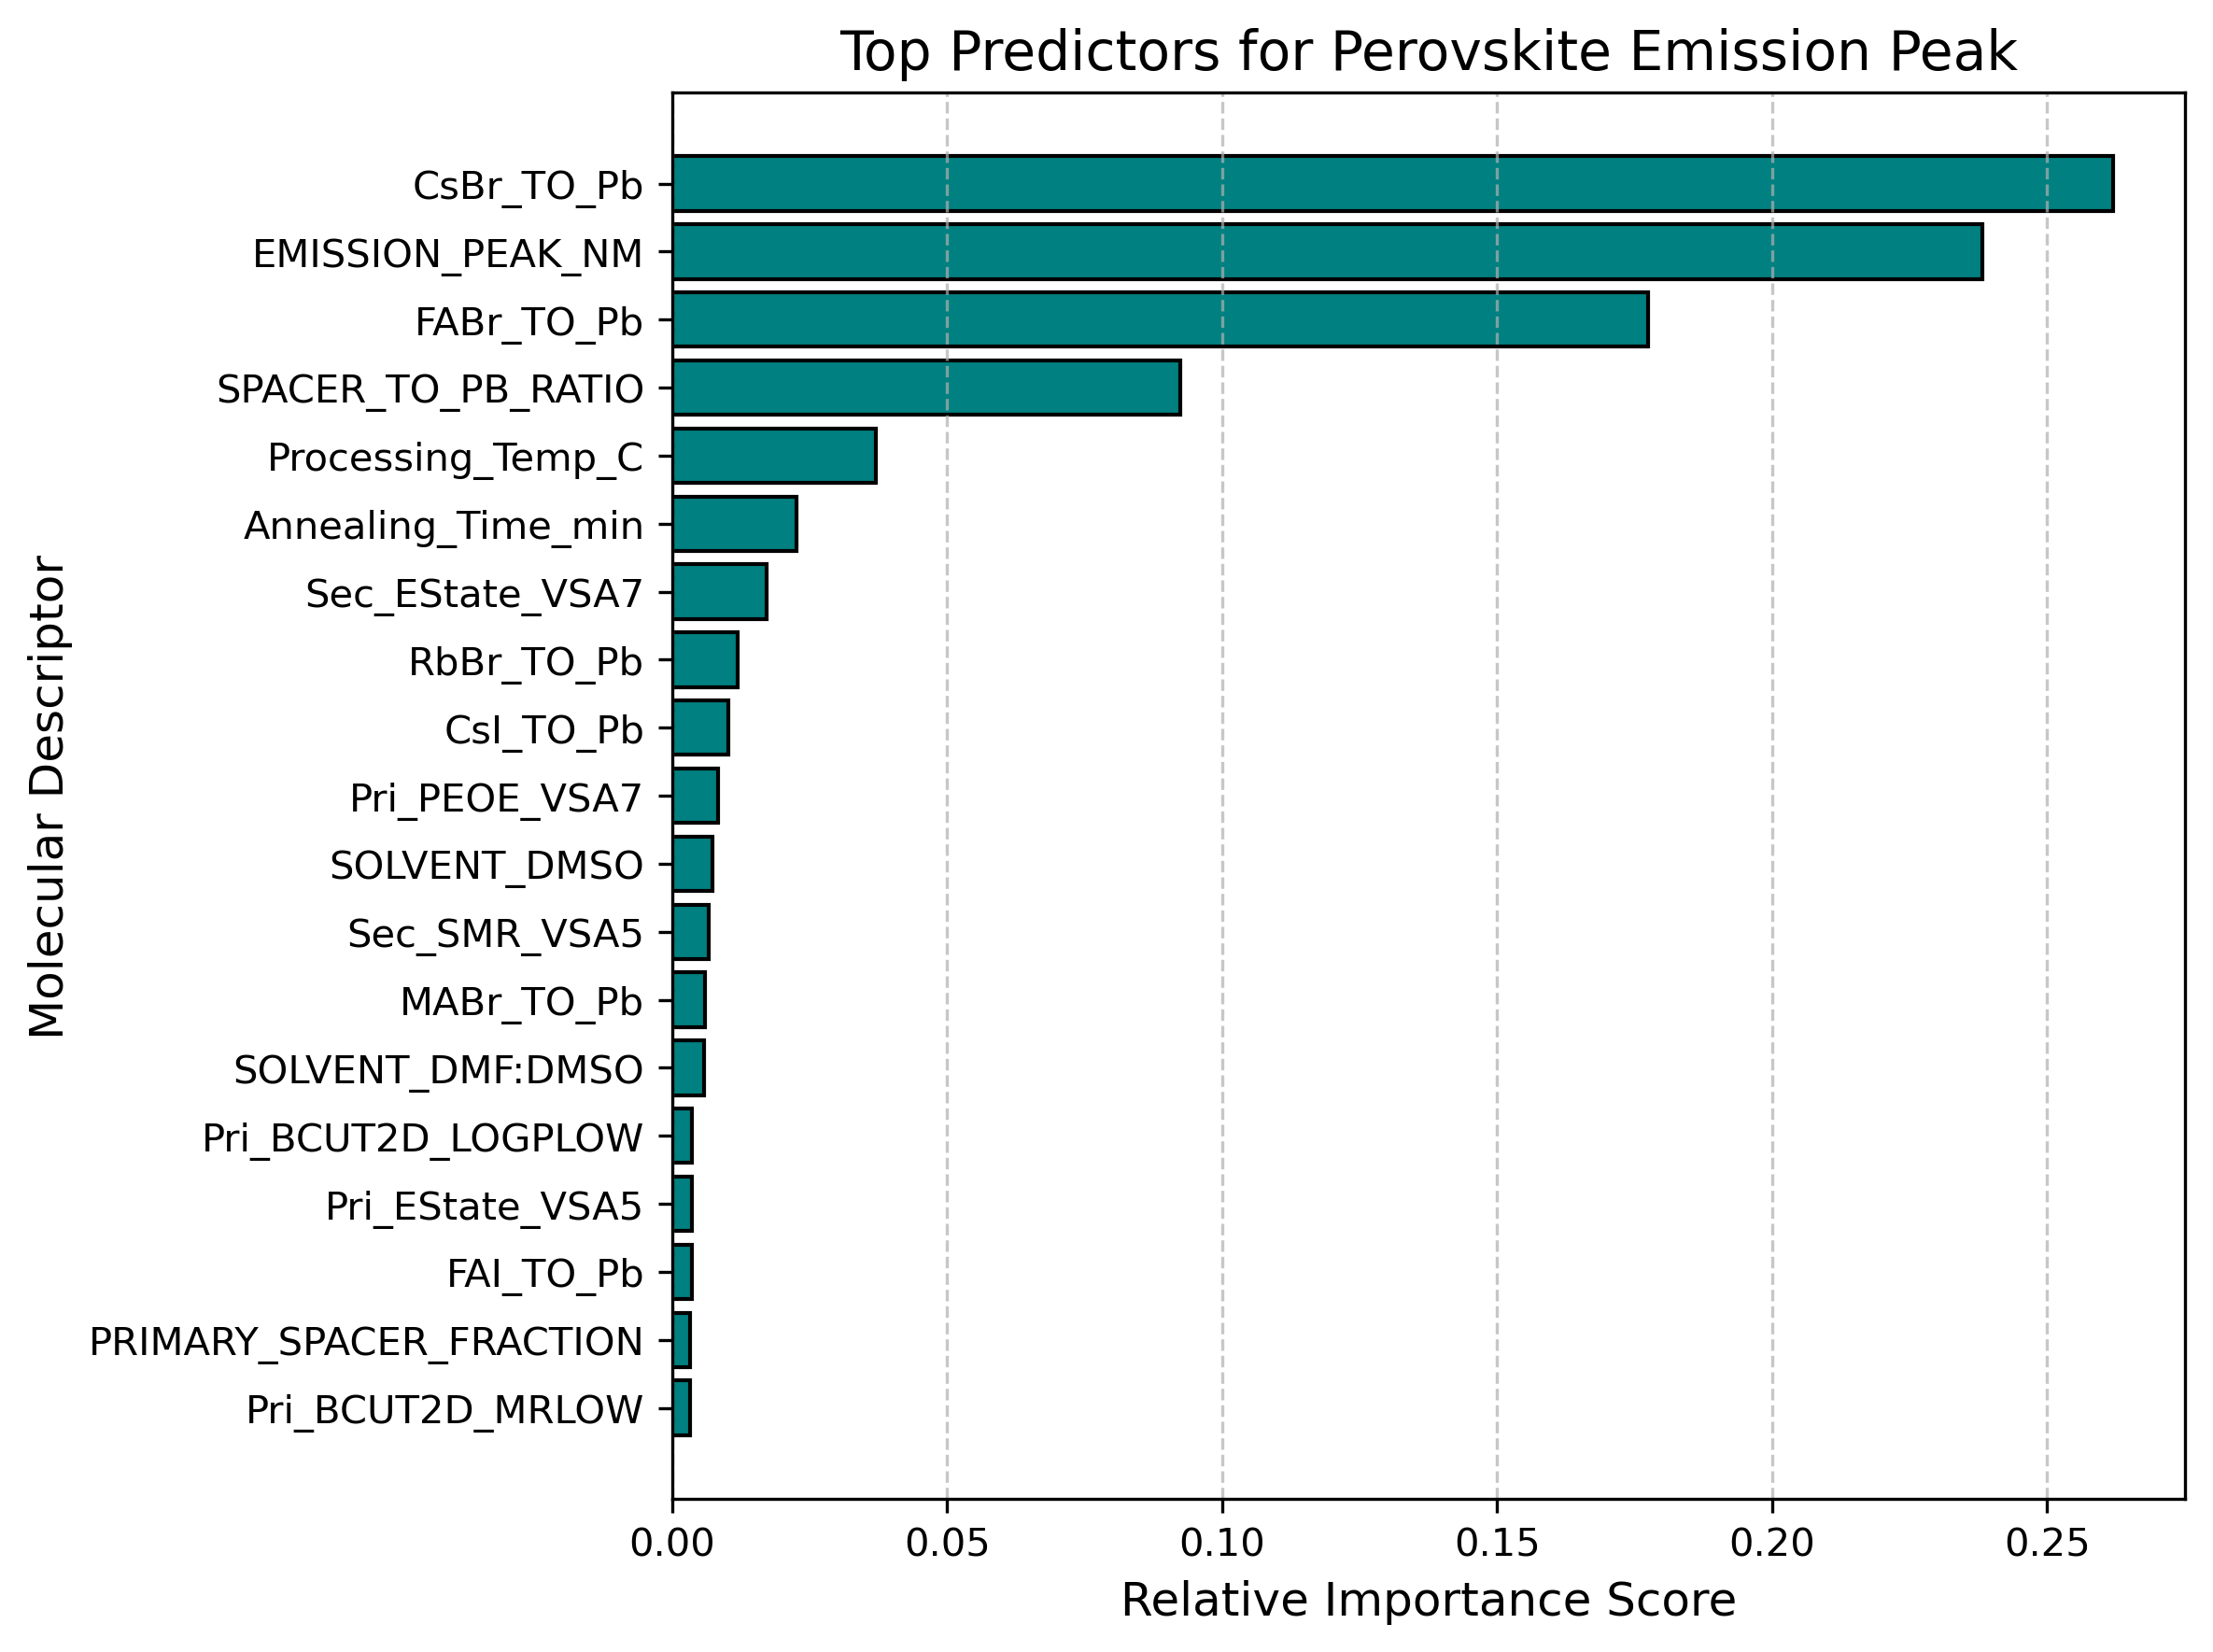

In [10]:
# Extract the importance scores from your Random Forest selector
importances = selector_model.feature_importances_[selected_feature_indices]
feature_names = X_train_final.columns

# Sort them from highest to lowest
sorted_indices = np.argsort(importances)
sorted_importances = importances[sorted_indices]
sorted_features = feature_names[sorted_indices]

# Create the Bar Chart
plt.figure(figsize=(8, 6), dpi=300)
plt.barh(sorted_features, sorted_importances, color='teal', edgecolor='black')

plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Molecular Descriptor", fontsize=12)
plt.title("Top Predictors for Perovskite Emission Peak", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Figure_2_Feature_Importance_RF_WL.png")
plt.show()

In [11]:
!pip install xgboost
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [12]:
# 1. Check for missing values in the training set
missing_train = X_train_final.isna().sum()
missing_train_fields = missing_train[missing_train > 0]

# 2. Check for missing values in the testing set
missing_test = X_test_final.isna().sum()
missing_test_fields = missing_test[missing_test > 0]

print("--- Columns with NaNs in X_train_final ---")
if missing_train_fields.empty:
    print("None! X_train_final is perfectly clean.")
else:
    print(missing_train_fields.to_string())

print("\n--- Columns with NaNs in X_test_final ---")
if missing_test_fields.empty:
    print("None! X_test_final is perfectly clean.")
else:
    print(missing_test_fields.to_string())
    
# 3. Quick peek at a row that contains a NaN
if not missing_train_fields.empty:
    print("\n--- Example row containing NaN in X_train_final ---")
    # Grab the first row that has a NaN value anywhere
    row_with_nan = X_train_final[X_train_final.isna().any(axis=1)].head(1)
    # Only display the columns that actually have NaNs
    print(row_with_nan[missing_train_fields.index].to_string())

--- Columns with NaNs in X_train_final ---
Sec_SMR_VSA5       183
Sec_EState_VSA7    183

--- Columns with NaNs in X_test_final ---
Sec_SMR_VSA5       45
Sec_EState_VSA7    45

--- Example row containing NaN in X_train_final ---
     Sec_SMR_VSA5  Sec_EState_VSA7
213           NaN              NaN


Executing CatBoost-Only Architecture Analysis...

Running hyperparameter search for CatBoost (incorporating device architecture)...

bestTest = 5.771349687
bestIteration = 295


bestTest = 5.725887045
bestIteration = 298


bestTest = 5.294471783
bestIteration = 484


bestTest = 6.451729651
bestIteration = 499


bestTest = 5.690883615
bestIteration = 499


bestTest = 5.600288596
bestIteration = 700


bestTest = 5.232288117
bestIteration = 346


bestTest = 5.393002578
bestIteration = 781


bestTest = 5.459526359
bestIteration = 231


bestTest = 5.607896416
bestIteration = 997


bestTest = 6.621021926
bestIteration = 299


bestTest = 6.971852342
bestIteration = 299


bestTest = 5.605298132
bestIteration = 666


bestTest = 5.459377154
bestIteration = 795


bestTest = 5.979488127
bestIteration = 799


bestTest = 5.679419276
bestIteration = 996


bestTest = 5.666780004
bestIteration = 286


bestTest = 6.21644868
bestIteration = 299


bestTest = 5.334472041
bestIteration = 491


bestTest = 5.

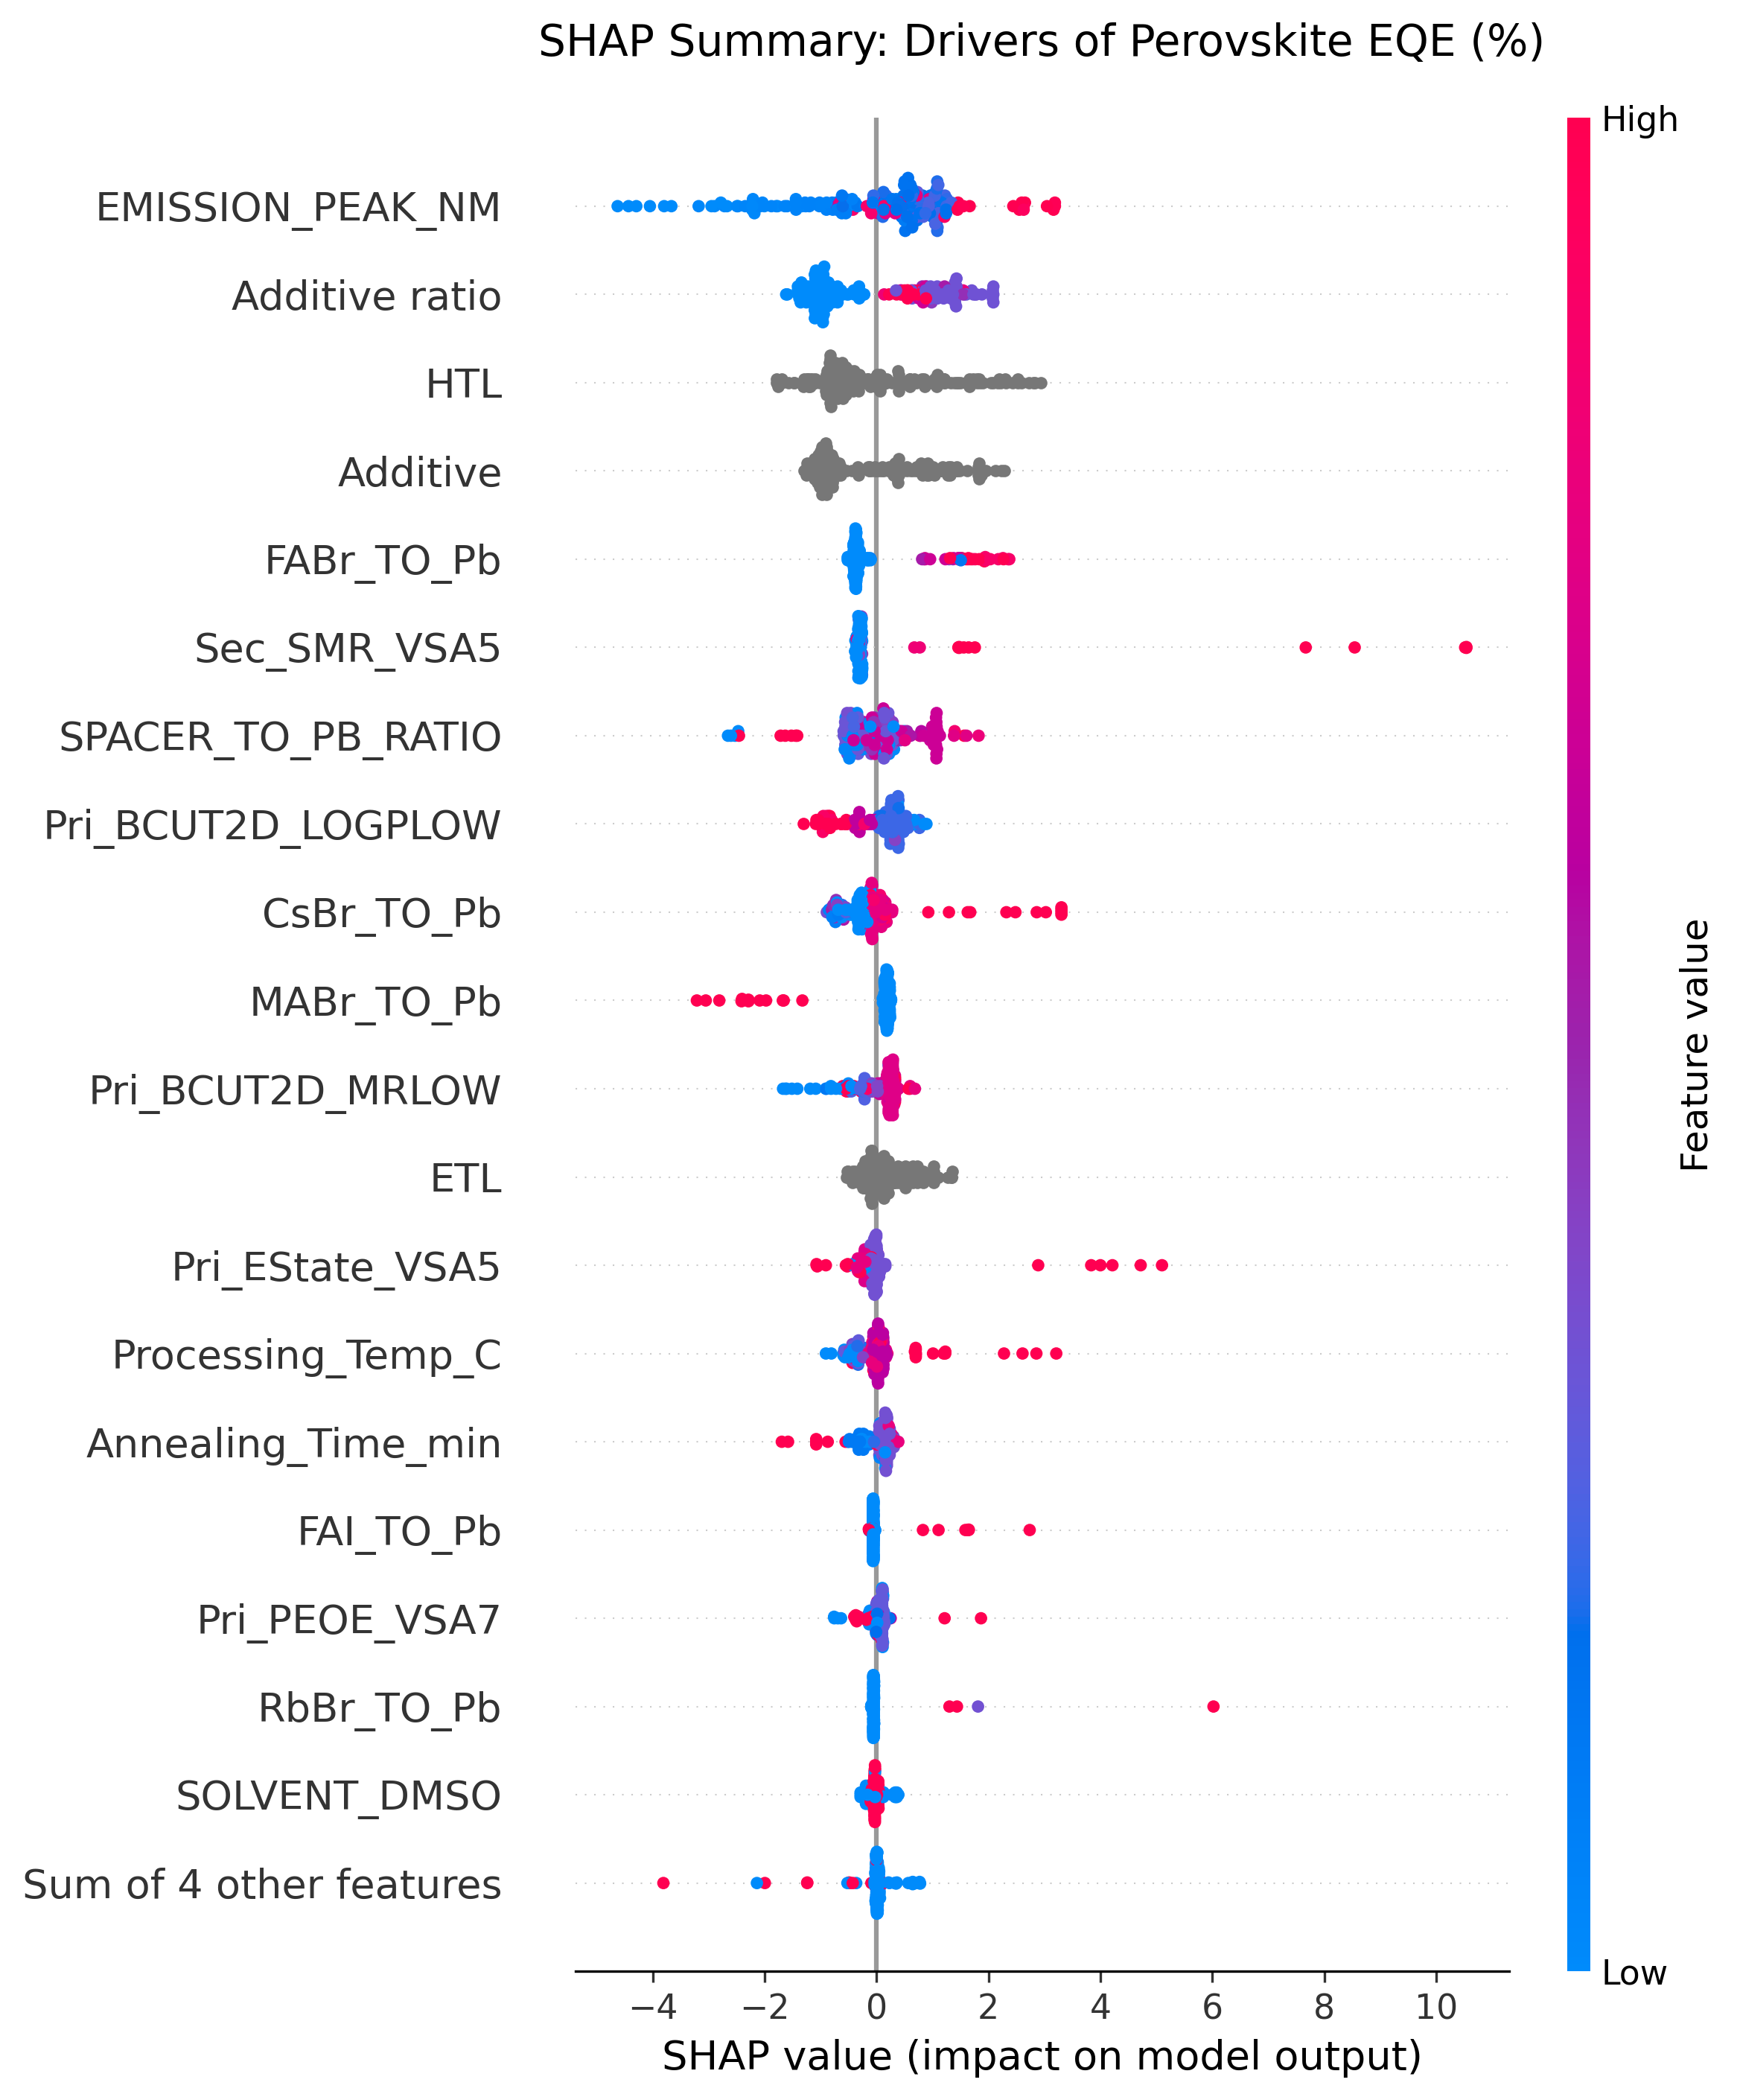

In [13]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

print("Executing CatBoost-Only Architecture Analysis...\n")

# ==========================================
# 1. CONCATENATE DATA & HANDLE NANs
# ==========================================
# Combine your numeric data and character data into single DataFrames
X_train_full = pd.concat([X_train_final, X_train_char], axis=1)
X_test_full = pd.concat([X_test_final, X_test_char], axis=1)

# Extract the list of categorical column names directly from your character dataframe
cat_features = list(X_train_char.columns)

# Safely patch any missing RDKit descriptors (numerics) with 0
num_features = list(X_train_final.columns)
X_train_full[num_features] = X_train_full[num_features].fillna(0)
X_test_full[num_features] = X_test_full[num_features].fillna(0)

# Ensure the categorical columns are strictly treated as strings
for col in cat_features:
    X_train_full[col] = X_train_full[col].astype(str)
    X_test_full[col] = X_test_full[col].astype(str)


# ==========================================
# 2. RIGOROUS CATBOOST TUNING 
# ==========================================
print("Running hyperparameter search for CatBoost (incorporating device architecture)...")

cat_grid = {
    'iterations': [300, 500, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 5, 6, 7],
    'l2_leaf_reg': [3, 5, 10, 15] # High L2 prevents memorizing rare Additives/HTLs
}

best_cat = CatBoostRegressor(cat_features=cat_features, verbose=0, random_seed=42)

# Native CatBoost randomized search
cat_search_results = best_cat.randomized_search(
    cat_grid,
    X=X_train_full,
    y=y_train,
    cv=5,                 
    n_iter=30,            
    verbose=False,
    plot=False
)

print(f"--> Best Parameters Found: {cat_search_results['params']}\n")


# ==========================================
# 3. FINAL EVALUATION
# ==========================================
y_pred = best_cat.predict(X_test_full)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("--- FINAL CATBOOST PERFORMANCE (WITH ARCHITECTURE) ---")
print(f"R2 Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f} % EQE")
print(f"MAE      : {mae:.4f} % EQE\n")


# ==========================================
# 4. ARCHITECTURE DEPENDENCY SHAP PLOT
# ==========================================
print("Generating native SHAP plot for device architecture...")

plt.figure(figsize=(10, 8), dpi=300)

explainer = shap.TreeExplainer(best_cat)
shap_values = explainer(X_train_full)

# This generates a beautiful plot showing exactly how much EQE is gained/lost 
# based on specific HTL, ETL, and Additive choices alongside molecular features
shap.plots.beeswarm(shap_values, max_display=20, show=False)

plt.title("SHAP Summary: Drivers of Perovskite EQE (%)", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("Figure_4_CatBoost_Architecture_SHAP.png", bbox_inches='tight')
plt.show()